# FAKE / UNFINISHED Final Project Over Time with Synethetic Data
Not to be graded 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import sigma_sb
from astropy import units as u

In [2]:

years = np.arange(1880, 2021)

data = []

for year in years:
    # Earth trends
    earth_co2 = 0.00028 + 0.0000015 * (year - 1880)   # rising CO2
    earth_temp = 287 + 0.015 * (year - 1880)          # rising temp
    earth_albedo = 0.30 - 0.00005 * (year - 1880)     # slight decrease
    earth_pressure = 1.0
    earth_expected = 255
    earth_deltaT = earth_temp - earth_expected

    data.append(["Earth", year, earth_co2, earth_pressure, earth_albedo,
                 earth_temp, earth_expected, earth_deltaT])

    # Mars trends
    mars_co2 = 0.95
    mars_pressure = 0.006
    mars_albedo = 0.25 + 0.02 * np.sin((year - 1880) / 5)  # dust cycles
    mars_temp = 210 + 3 * np.sin((year - 1880) / 5)
    mars_expected = 210
    mars_deltaT = mars_temp - mars_expected

    data.append(["Mars", year, mars_co2, mars_pressure, mars_albedo,
                 mars_temp, mars_expected, mars_deltaT])

    # Venus trends
    venus_co2 = 0.965
    venus_pressure = 92
    venus_albedo = 0.75 + 0.005 * np.sin((year - 1880) / 11)  # cloud cycles
    venus_temp = 735 - 0.02 * (year - 1880)                   # slight cooling
    venus_expected = 230
    venus_deltaT = venus_temp - venus_expected

    data.append(["Venus", year, venus_co2, venus_pressure, venus_albedo,
                 venus_temp, venus_expected, venus_deltaT])

df_time = pd.DataFrame(data, columns=[
    "planet", "year", "co2_fraction", "pressure_bar", "albedo",
    "actual_temp_K", "expected_temp_K", "delta_T"
])

df_time["greenhouse_strength"] = df_time["pressure_bar"] * df_time["co2_fraction"]

df_time.head()

,planet,year,co2_fraction,pressure_bar,albedo,actual_temp_K,expected_temp_K,delta_T,greenhouse_strength
0,Earth,1880,0.000280,1.000,0.300000,287.000000,255,32.000000,0.000280
1,Mars,1880,0.950000,0.006,0.250000,210.000000,210,0.000000,0.005700
2,Venus,1880,0.965000,92.000,0.750000,735.000000,230,505.000000,88.780000
3,Earth,1881,0.000281,1.000,0.299950,287.015000,255,32.015000,0.000281
4,Mars,1881,0.950000,0.006,0.253973,210.596008,210,0.596008,0.005700


In [3]:
df_time.shape

(423, 9)

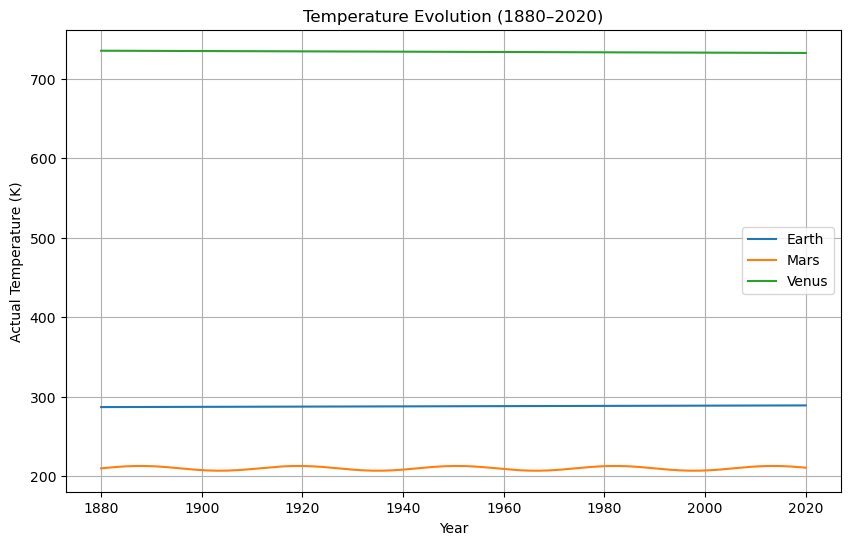

In [4]:
plt.figure(figsize=(10,6))

for planet in df_time["planet"].unique():
    subset = df_time[df_time["planet"] == planet]
    plt.plot(subset["year"], subset["actual_temp_K"], label=planet)

plt.xlabel("Year")
plt.ylabel("Actual Temperature (K)")
plt.title("Temperature Evolution (1880–2020)")
plt.legend()
plt.grid(True)
plt.show()

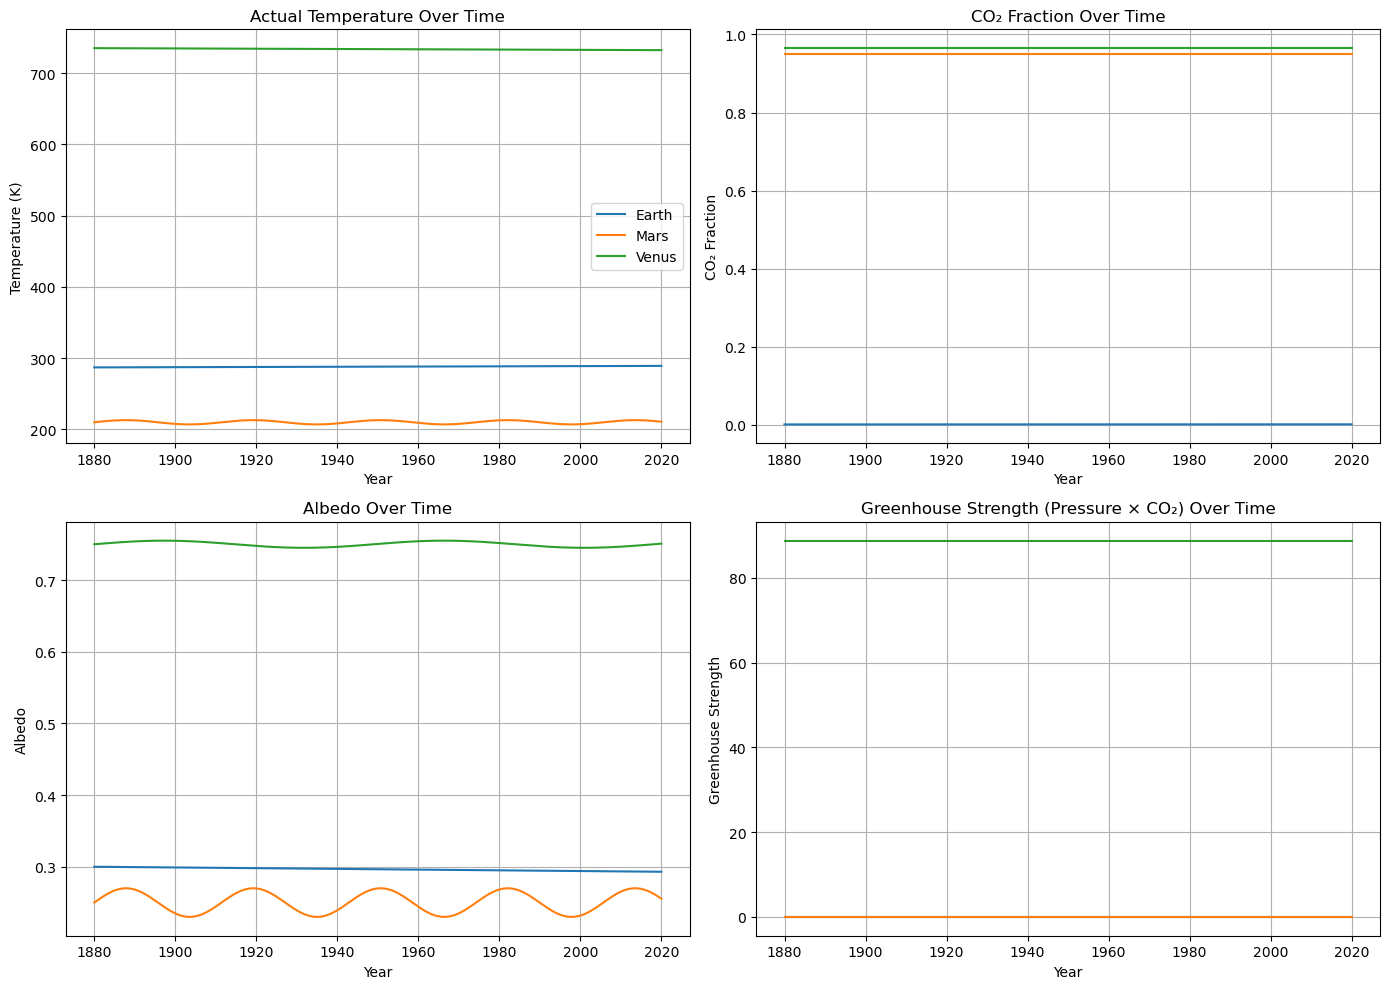

In [7]:
planets = df_time["planet"].unique()

fig, axes = plt.subplots(2, 2, figsize=(14,10))
(ax1, ax2), (ax3, ax4) = axes

# --- Temperature vs Time ---
for planet in planets:
    subset = df_time[df_time["planet"] == planet]
    ax1.plot(subset["year"], subset["actual_temp_K"], label=planet)
ax1.set_title("Actual Temperature Over Time")
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature (K)")
ax1.grid(True)
ax1.legend()

# --- CO2 Fraction vs Time ---
for planet in planets:
    subset = df_time[df_time["planet"] == planet]
    ax2.plot(subset["year"], subset["co2_fraction"], label=planet)
ax2.set_title("CO₂ Fraction Over Time")
ax2.set_xlabel("Year")
ax2.set_ylabel("CO₂ Fraction")
ax2.grid(True)

# --- Albedo vs Time ---
for planet in planets:
    subset = df_time[df_time["planet"] == planet]
    ax3.plot(subset["year"], subset["albedo"], label=planet)
ax3.set_title("Albedo Over Time")
ax3.set_xlabel("Year")
ax3.set_ylabel("Albedo")
ax3.grid(True)

# --- Greenhouse Strength vs Time ---
for planet in planets:
    subset = df_time[df_time["planet"] == planet]
    ax4.plot(subset["year"], subset["greenhouse_strength"], label=planet)
ax4.set_title("Greenhouse Strength (Pressure × CO₂) Over Time")
ax4.set_xlabel("Year")
ax4.set_ylabel("Greenhouse Strength")
ax4.grid(True)

plt.tight_layout()
plt.show()


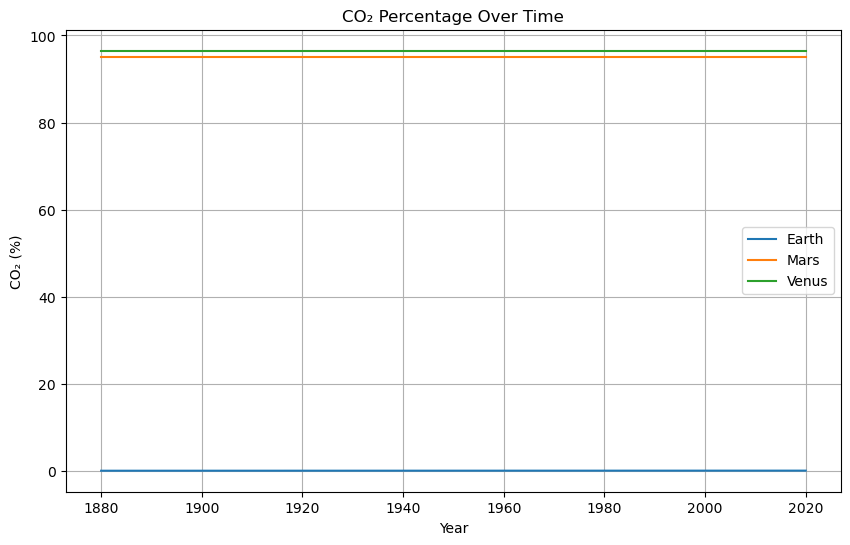

In [8]:
df_time["co2_percent"] = df_time["co2_fraction"] * 100

plt.figure(figsize=(10,6))

for planet in df_time["planet"].unique():
    subset = df_time[df_time["planet"] == planet]
    plt.plot(subset["year"], subset["co2_percent"], label=planet)

plt.xlabel("Year")
plt.ylabel("CO₂ (%)")
plt.title("CO₂ Percentage Over Time")
plt.grid(True)
plt.legend()
plt.show()


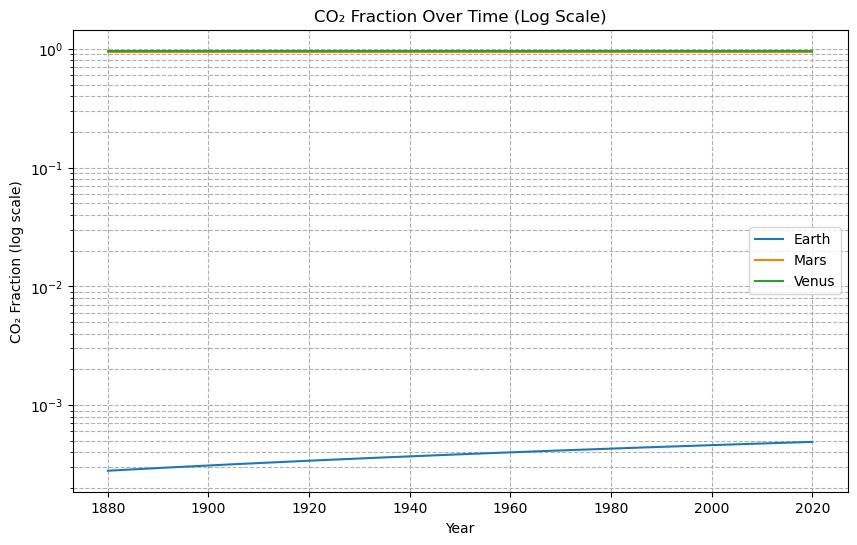

In [9]:
plt.figure(figsize=(10,6))

for planet in df_time["planet"].unique():
    subset = df_time[df_time["planet"] == planet]
    plt.plot(subset["year"], subset["co2_fraction"], label=planet)

plt.yscale("log")
plt.xlabel("Year")
plt.ylabel("CO₂ Fraction (log scale)")
plt.title("CO₂ Fraction Over Time (Log Scale)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


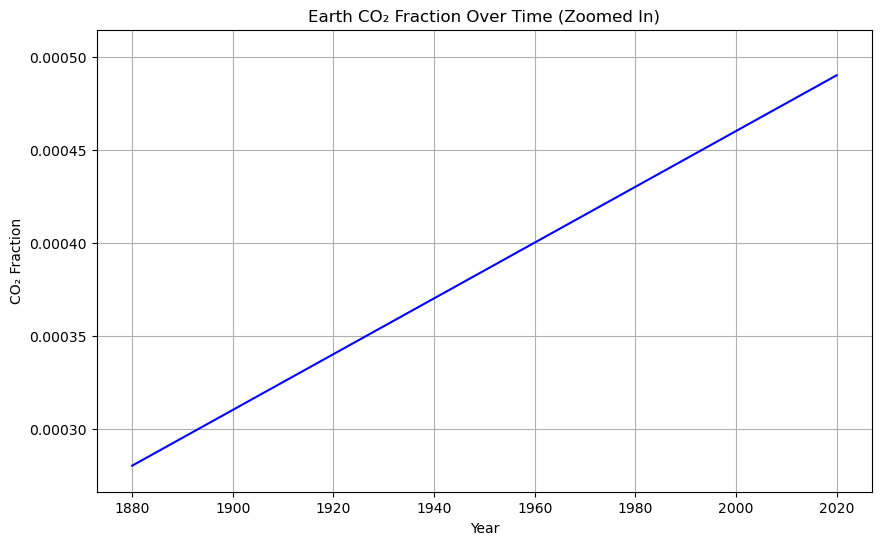

In [12]:
plt.figure(figsize=(10,6))

earth = df_time[df_time["planet"] == "Earth"]
plt.plot(earth["year"], earth["co2_fraction"], color="blue")

plt.xlabel("Year")
plt.ylabel("CO₂ Fraction")
plt.title("Earth CO₂ Fraction Over Time (Zoomed In)")
plt.grid(True)

# Zoom in around Earth's actual range
plt.ylim(earth["co2_fraction"].min() * 0.95,
         earth["co2_fraction"].max() * 1.05)

plt.show()


Again, another stage of the final project where we tried to do a long-term sort of thing but again this is fake because it was just very hard to find real data and also some things (like CO2 fraction over time for mars and Venus) don't really change over time scales for the planets besides earth because the whole point of our current greenhouse effect is that the presence of humans has messed with the climate but of course Mars and Venus don't have humans and the major changes in their atmospheres/ surfaces (including venus' runaway effect) took place a really long time ago. If anything, this notebook was good to practice subplots and showed us what we don't want (time scale graphs) or don't need (astropy honestly irrelevant as you'll see in our actual final project) for the real deal. 
Basically a lesson in overcomplicating the project and then walking it back like 400 steps.